# V1 Experiment Evaluation

Auto-discovering evaluation notebook for the v1 experimental framework.
Analyzes results across 5 models × 4 context conditions (c0-c3).

In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Auto-discover model folders
V1_DIR = Path(".").resolve()
MODEL_DIRS = [d for d in V1_DIR.iterdir() if d.is_dir() and not d.name.startswith(".")]
print(f"Discovered model folders: {[d.name for d in MODEL_DIRS]}")

Discovered model folders: ['ministral_8b', 'gpt_5_2_openai', 'mistral_medium']


In [2]:
# Style configuration for thesis-quality visualizations
plt.rcParams.update({"figure.dpi": 150, "axes.titlesize": 14, "axes.labelsize": 12})
sns.set_theme(style="whitegrid", palette="colorblind")
CONTEXT_COLORS = {"c0": "#1f77b4", "c1": "#ff7f0e", "c2": "#2ca02c", "c3": "#d62728"}

In [3]:
def load_results(model_dir: Path) -> list[dict]:
    """Load all JSON result files from a model directory."""
    results = []
    for json_file in model_dir.glob("*.json"):
        with open(json_file) as f:
            data = json.load(f)
            data["_file"] = json_file.name
            data["_model_dir"] = model_dir.name
            results.append(data)
    return results

# Load all results
all_results = []
for model_dir in MODEL_DIRS:
    all_results.extend(load_results(model_dir))

print(f"Loaded {len(all_results)} result files")

Loaded 8 result files


In [4]:
def extract_metrics(result: dict) -> list[dict]:
    """Extract per-dataset metrics from a result file."""
    rows = []
    config = result.get("config", {})
    model_dir = result.get("_model_dir", "unknown")
    experiment = config.get("experiment", {}).get("experiment_name", "unknown")
    model = config.get("llm", {}).get("model", "unknown")
    context_sources = config.get("context", {}).get("sources", [])
    
    # JSON uses "datasets" key, not "results"
    for dataset, metrics in result.get("datasets", {}).items():
        reports = metrics.get("reports", {})
        for manipulation in ["original", "content_only", "shuffle"]:
            report = reports.get(manipulation, {})
            macro_f1 = report.get("macro avg", {}).get("f1-score", np.nan)
            accuracy = report.get("accuracy", np.nan)
            
            rows.append({
                "model_dir": model_dir,
                "model": model,
                "context": experiment,
                "context_sources": ", ".join(context_sources),
                "dataset": dataset,
                "manipulation": manipulation,
                "macro_f1": macro_f1,
                "accuracy": accuracy,
            })
    return rows

# Build flat DataFrame
rows = []
for result in all_results:
    rows.extend(extract_metrics(result))

df = pd.DataFrame(rows)
print(f"Built DataFrame with {len(df)} rows")
df.head(10)

Built DataFrame with 186 rows


,model_dir,model,context,context_sources,dataset,manipulation,macro_f1,accuracy
0,ministral_8b,ministral-8b-latest,c1,definition,ABSTRCT,original,0.833148,0.833333
1,ministral_8b,ministral-8b-latest,c1,definition,ABSTRCT,content_only,0.583207,0.616667
2,ministral_8b,ministral-8b-latest,c1,definition,ABSTRCT,shuffle,0.384405,0.500000
3,ministral_8b,ministral-8b-latest,c1,definition,ACQUA,original,0.744246,0.750000
4,ministral_8b,ministral-8b-latest,c1,definition,ACQUA,content_only,0.515455,0.516667
5,ministral_8b,ministral-8b-latest,c1,definition,ACQUA,shuffle,0.523810,0.600000
6,ministral_8b,ministral-8b-latest,c1,definition,AEC,original,0.497768,0.500000
7,ministral_8b,ministral-8b-latest,c1,definition,AEC,content_only,0.484127,0.566667
8,ministral_8b,ministral-8b-latest,c1,definition,AEC,shuffle,0.333333,0.500000
9,ministral_8b,ministral-8b-latest,c1,definition,AFS,original,0.698661,0.700000


## C1 Fallback for C2/C3 Aggregate Calculations

**Important:** c2 and c3 only run on 4 datasets with annotation guidelines:
- ABSTRCT, ARGUMINSCI, PE, USELEC

The remaining 6 datasets (ACQUA, AEC, AFS, FINARG, IAM, SCIARK) don't have guidelines, so:
- **c2/c3 cannot provide additional context beyond c1 for these datasets**
- **For aggregate metrics, we use c1 results as the effective c2/c3 performance**

This ensures fair 10-dataset comparisons across all context conditions.

In [5]:
# =============================================================================
# C1 FALLBACK LOGIC FOR C2/C3
# =============================================================================
# Datasets WITH guidelines (run in c2/c3):
GUIDELINE_DATASETS = {"ABSTRCT", "ARGUMINSCI", "PE", "USELEC"}

# Datasets WITHOUT guidelines (use c1 results for c2/c3):
NO_GUIDELINE_DATASETS = {"ACQUA", "AEC", "AFS", "FINARG", "IAM", "SCIARK"}

def fill_c2_c3_with_c1_fallback(df: pd.DataFrame) -> pd.DataFrame:
    """
    For c2/c3 aggregate calculations, fill missing datasets with c1 results.
    Only adds fallback for models that actually have c2/c3 results.
    """
    if df.empty:
        return df

    df_filled = df.copy()

    for target_context in ["c2", "c3"]:
        # Get models that have actual results for this context (on guideline datasets)
        models_with_ctx = df[
            (df["context"] == target_context) &
            (df["dataset"].isin(GUIDELINE_DATASETS))
        ]["model_dir"].unique()

        if len(models_with_ctx) == 0:
            continue

        # Get c1 data for non-guideline datasets, only for those models
        fallback = df[
            (df["context"] == "c1") &
            (df["model_dir"].isin(models_with_ctx)) &
            (df["dataset"].isin(NO_GUIDELINE_DATASETS))
        ].copy()

        if not fallback.empty:
            fallback["context"] = target_context
            fallback["context_sources"] = "[c1 fallback]"
            df_filled = pd.concat([df_filled, fallback], ignore_index=True)
            print(f"Added c1 fallback for {target_context}: {len(fallback)} rows for {list(models_with_ctx)}")

    return df_filled

# Create filled DataFrame for aggregate calculations
df_filled = fill_c2_c3_with_c1_fallback(df)

# Show what was added
if not df_filled.empty:
    actual_contexts = df["context"].unique()
    filled_contexts = df_filled["context"].unique()
    print(f"\nOriginal df: {len(df)} rows, contexts: {sorted(actual_contexts)}")
    print(f"Filled df:   {len(df_filled)} rows, contexts: {sorted(filled_contexts)}")
    
    # Show c2/c3 details only if they exist
    for ctx in ["c2", "c3"]:
        if ctx in filled_contexts:
            ctx_datasets = df_filled[df_filled["context"] == ctx]["dataset"].unique()
            print(f"\n{ctx} datasets: {sorted(ctx_datasets)}")
else:
    print("No data loaded yet")

Added c1 fallback for c2: 54 rows for ['ministral_8b', 'gpt_5_2_openai', 'mistral_medium']

Original df: 186 rows, contexts: ['c0', 'c1', 'c2']
Filled df:   240 rows, contexts: ['c0', 'c1', 'c2']

c2 datasets: ['ABSTRCT', 'ACQUA', 'AEC', 'AFS', 'ARGUMINSCI', 'FINARG', 'IAM', 'PE', 'SCIARK', 'USELEC']


## Performance Overview

In [6]:
# =============================================================================
# USING df_filled: c2/c3 include c1 fallback for non-guideline datasets
# =============================================================================
original_df_filled = df_filled[df_filled["manipulation"] == "original"]

pivot_f1 = original_df_filled.pivot_table(
    values="macro_f1",
    index="model_dir",
    columns="context",
    aggfunc="mean"
)

# Reorder columns if they exist
col_order = [c for c in ["c0", "c1", "c2", "c3"] if c in pivot_f1.columns]
if col_order:
    pivot_f1 = pivot_f1[col_order]

print("Mean Macro-F1 (Original Text) by Model × Context")
print("NOTE: c2/c3 averages include c1 fallback for 6 non-guideline datasets")
pivot_f1.round(3)

Mean Macro-F1 (Original Text) by Model × Context
NOTE: c2/c3 averages include c1 fallback for 6 non-guideline datasets


context,c0,c1,c2
model_dir,,,
gpt_5_2_openai,0.567,0.674,0.693
ministral_8b,NaN,0.664,0.670
mistral_medium,0.606,0.704,0.701


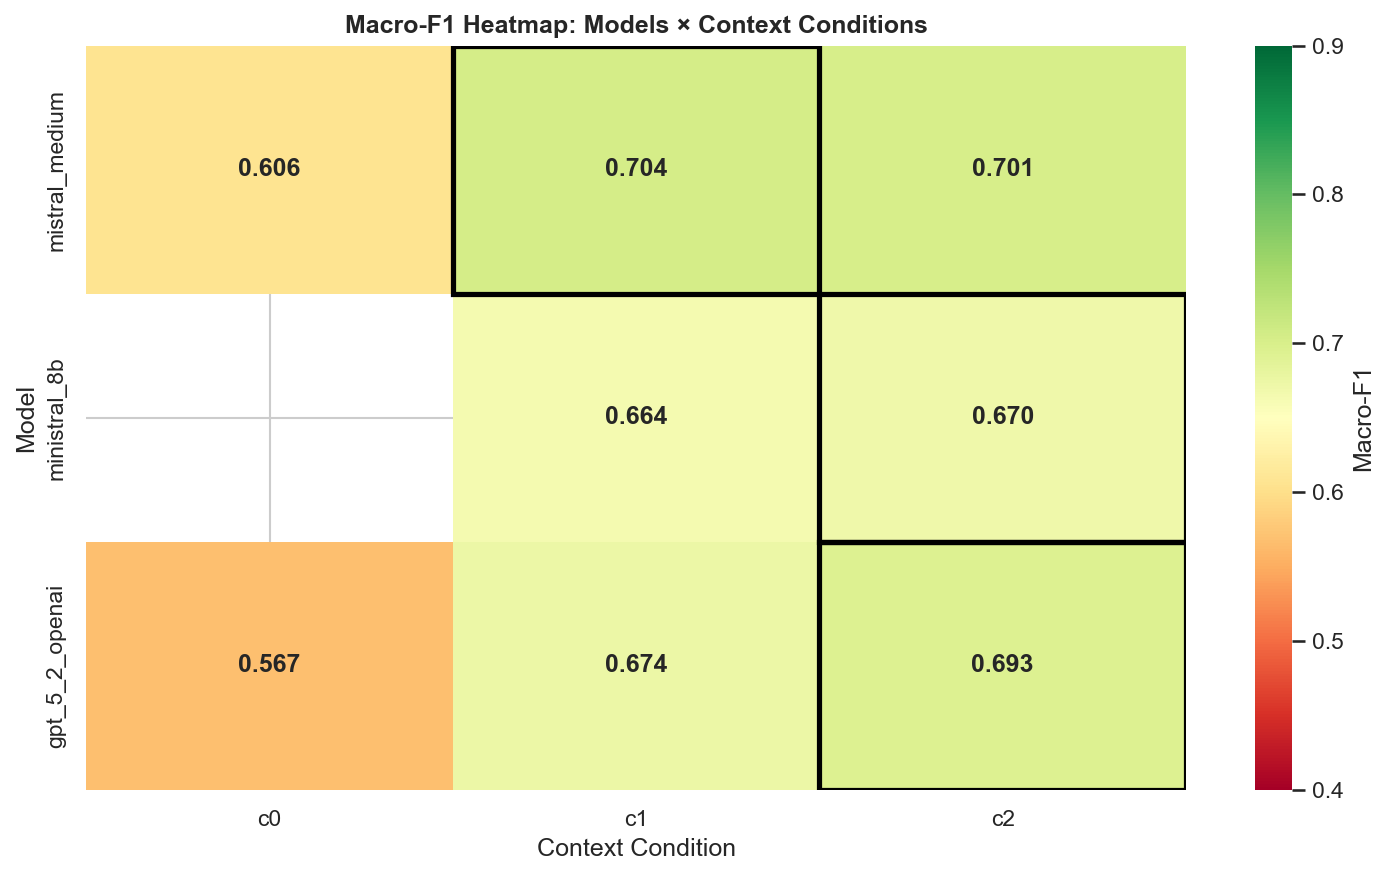

In [7]:
# F1 Heatmap with enhanced styling
from matplotlib.patches import Rectangle

if not pivot_f1.empty:
    # Sort models by mean F1 descending
    pivot_f1_sorted = pivot_f1.loc[pivot_f1.mean(axis=1).sort_values(ascending=False).index]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(pivot_f1_sorted, annot=True, fmt=".3f", cmap="RdYlGn", 
                vmin=0.4, vmax=0.9, ax=ax,
                annot_kws={"size": 12, "weight": "bold"},
                cbar_kws={"label": "Macro-F1"})
    
    # Highlight max per row with rectangle
    for i, row in enumerate(pivot_f1_sorted.values):
        if not np.all(np.isnan(row)):
            j = np.nanargmax(row)
            ax.add_patch(Rectangle((j, i), 1, 1, fill=False, 
                                    edgecolor="black", linewidth=2.5))
    
    ax.set_title("Macro-F1 Heatmap: Models × Context Conditions", fontweight="bold")
    ax.set_xlabel("Context Condition")
    ax.set_ylabel("Model")
    plt.tight_layout()
    plt.show()
else:
    print("No data available for heatmap")

## Delta Analysis (Shortcut Learning)

In [8]:
# Calculate deltas: Content-Only and Shuffle vs Original
# Using df_filled for consistent 10-dataset comparison across all contexts
def calculate_deltas(df: pd.DataFrame) -> pd.DataFrame:
    """Calculate delta_content_only and delta_shuffle for each model/context/dataset."""
    pivot = df.pivot_table(
        values="macro_f1",
        index=["model_dir", "context", "dataset"],
        columns="manipulation",
        aggfunc="mean"
    ).reset_index()
    
    if "original" in pivot.columns:
        if "content_only" in pivot.columns:
            pivot["delta_content_only"] = pivot["content_only"] - pivot["original"]
        if "shuffle" in pivot.columns:
            pivot["delta_shuffle"] = pivot["shuffle"] - pivot["original"]
    
    return pivot

deltas_df = calculate_deltas(df_filled)  # Using df_filled!
deltas_df.head()

manipulation,model_dir,context,dataset,content_only,original,shuffle,delta_content_only,delta_shuffle
0,gpt_5_2_openai,c0,ABSTRCT,0.601140,0.691936,0.601140,-0.090796,-0.090796
1,gpt_5_2_openai,c0,ACQUA,0.394334,0.618056,0.537869,-0.223721,-0.080186
2,gpt_5_2_openai,c0,AEC,0.449193,0.562290,0.444444,-0.113097,-0.117845
3,gpt_5_2_openai,c0,AFS,0.587500,0.568842,0.576380,0.018658,0.007538
4,gpt_5_2_openai,c0,ARGUMINSCI,0.333333,0.523810,0.333333,-0.190476,-0.190476


In [9]:
# Mean deltas by model and context
if "delta_content_only" in deltas_df.columns and "delta_shuffle" in deltas_df.columns:
    delta_summary = deltas_df.groupby(["model_dir", "context"])[["delta_content_only", "delta_shuffle"]].mean()
    print("Mean Deltas (negative = performance drop under manipulation)")
    display(delta_summary.round(3))
else:
    print("Not enough manipulations to calculate deltas")

Mean Deltas (negative = performance drop under manipulation)


manipulation            delta_content_only  delta_shuffle
model_dir      context                                   
gpt_5_2_openai c0                   -0.091         -0.086
               c1                   -0.126         -0.197
               c2                   -0.099         -0.188
ministral_8b   c1                   -0.158         -0.291
               c2                   -0.124         -0.279
mistral_medium c0                   -0.030         -0.148
               c1                   -0.137         -0.247
               c2                   -0.112         -0.221

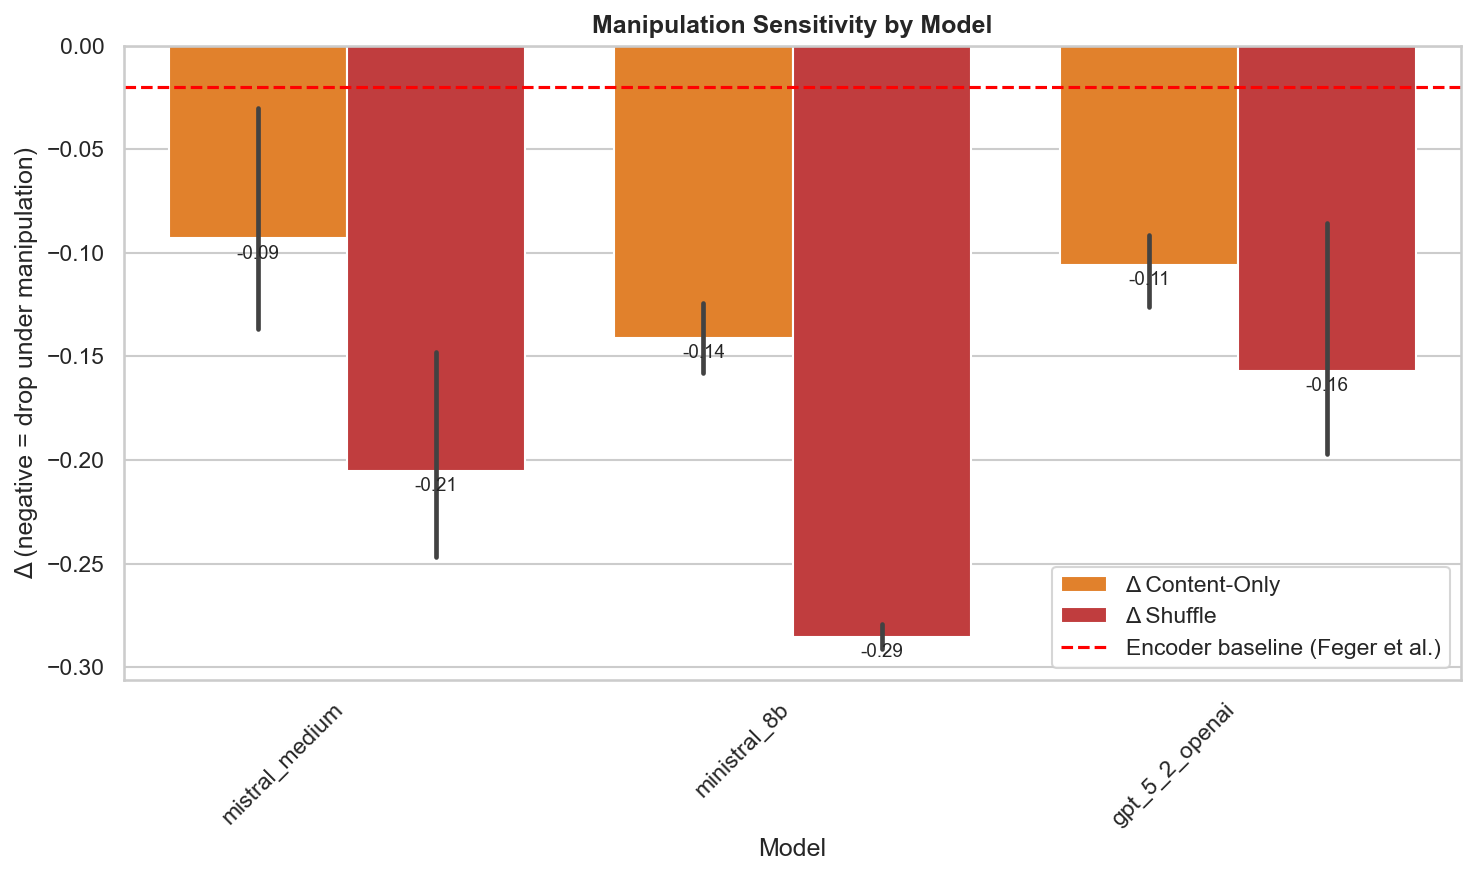

In [10]:
# =============================================================================
# DELTA BAR CHART: Manipulation Sensitivity by Model
# =============================================================================
if "delta_content_only" in deltas_df.columns and "delta_shuffle" in deltas_df.columns:
    # Prepare delta summary for plotting
    delta_plot = delta_summary.reset_index()
    delta_melted = delta_plot.melt(
        id_vars=["model_dir", "context"],
        value_vars=["delta_content_only", "delta_shuffle"],
        var_name="manipulation",
        value_name="delta"
    )
    # Rename for cleaner legend
    delta_melted["manipulation"] = delta_melted["manipulation"].map({
        "delta_content_only": "Δ Content-Only",
        "delta_shuffle": "Δ Shuffle"
    })
    
    # Sort models by mean F1 descending
    model_order = pivot_f1.mean(axis=1).sort_values(ascending=False).index.tolist()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=delta_melted, x="model_dir", y="delta", hue="manipulation", 
                ax=ax, order=model_order, palette=["#ff7f0e", "#d62728"])
    
    # Reference lines
    ax.axhline(0, color="black", linewidth=1)
    ax.axhline(-0.02, color="red", linestyle="--", linewidth=1.5, 
               label="Encoder baseline (Feger et al.)")
    
    # Value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)
    
    ax.set_ylabel("Δ (negative = drop under manipulation)")
    ax.set_xlabel("Model")
    ax.set_title("Manipulation Sensitivity by Model", fontweight="bold")
    ax.legend(loc="lower right")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data for delta bar chart")

## Per-Dataset Performance

In [11]:
# Per-dataset F1 for c1 (definition context)
c1_original = df[(df["context"] == "c1") & (df["manipulation"] == "original")]

if not c1_original.empty:
    per_dataset = c1_original.pivot_table(
        values="macro_f1",
        index="dataset",
        columns="model_dir",
        aggfunc="mean"
    )
    print("c1 (Definition) Macro-F1 by Dataset × Model")
    display(per_dataset.round(3))
else:
    print("No c1 results available")

c1 (Definition) Macro-F1 by Dataset × Model


model_dir,gpt_5_2_openai,ministral_8b,mistral_medium
dataset,,,
ABSTRCT,0.663,0.833,0.900
ACQUA,0.749,0.744,0.764
AEC,0.498,0.498,0.486
AFS,0.767,0.699,0.766
ARGUMINSCI,0.917,0.733,0.757
FINARG,0.438,0.542,0.583
IAM,0.764,0.681,0.782
PE,0.600,0.697,0.603
SCIARK,0.717,0.633,0.783


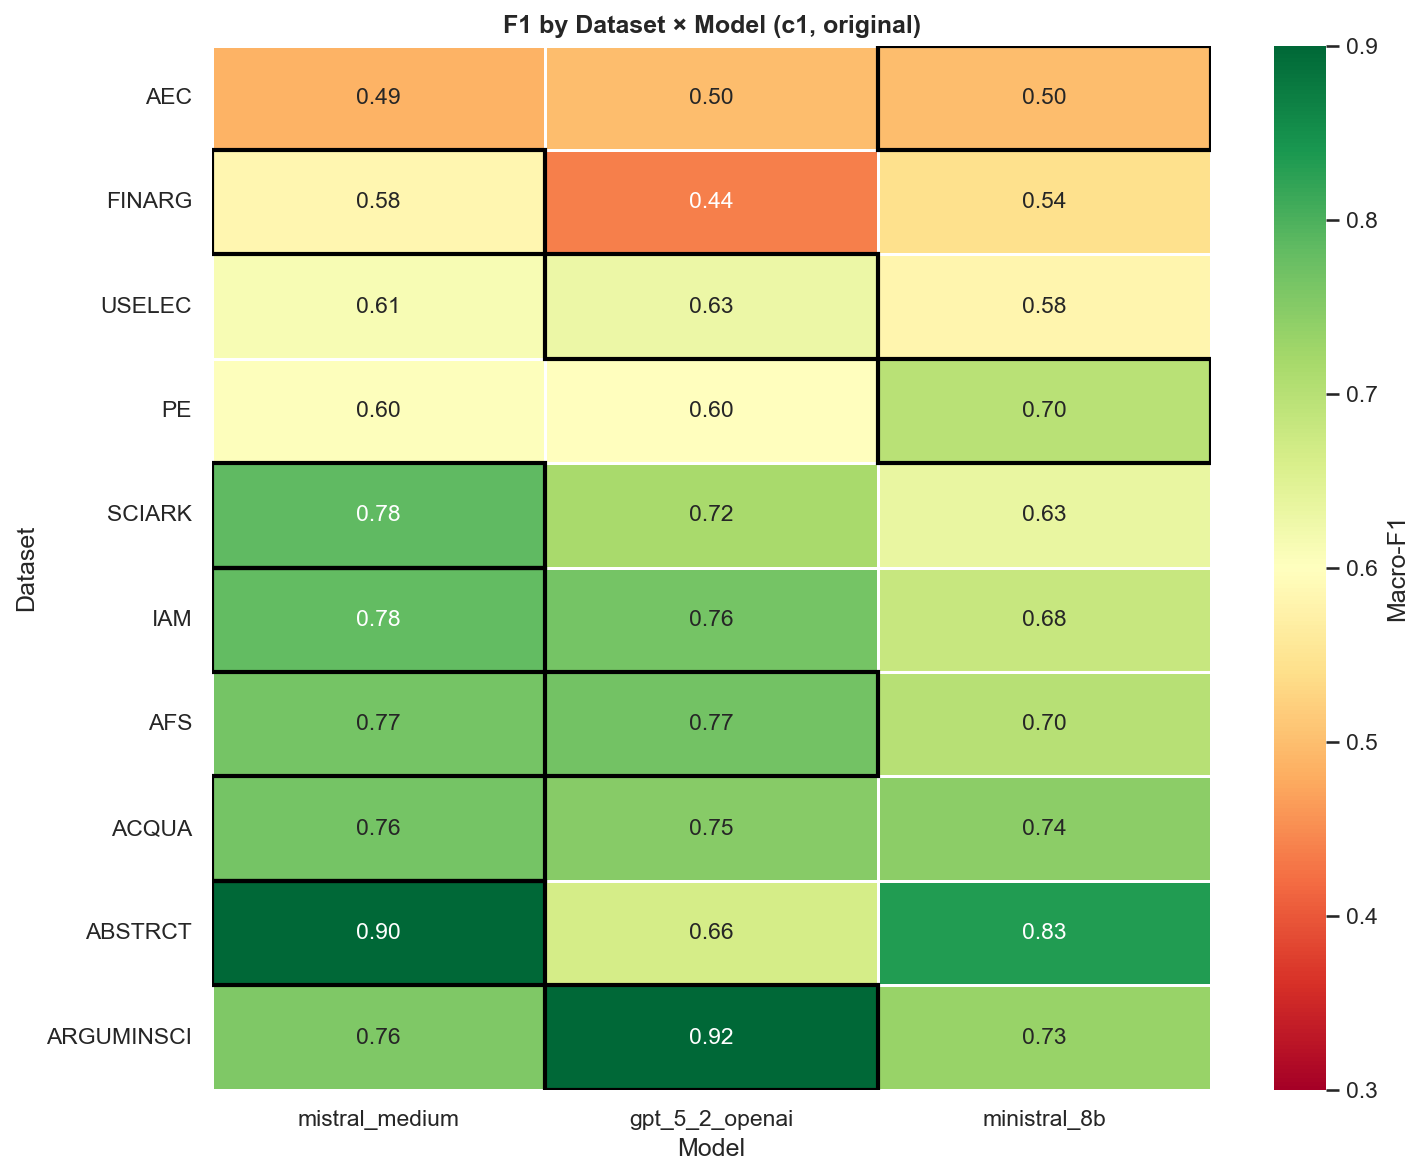

In [12]:
# =============================================================================
# PER-DATASET HEATMAP: F1 by Dataset × Model
# =============================================================================
if not c1_original.empty:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Sort datasets by mean F1, models by mean F1
    sorted_pivot = per_dataset.loc[per_dataset.mean(axis=1).sort_values().index]
    sorted_pivot = sorted_pivot[sorted_pivot.mean().sort_values(ascending=False).index]
    
    sns.heatmap(sorted_pivot, annot=True, fmt=".2f", cmap="RdYlGn",
                vmin=0.3, vmax=0.9, linewidths=0.5, ax=ax,
                annot_kws={"size": 11},
                cbar_kws={"label": "Macro-F1"})
    
    # Highlight max per row with rectangle
    for i, row in enumerate(sorted_pivot.values):
        if not np.all(np.isnan(row)):
            j = np.nanargmax(row)
            ax.add_patch(Rectangle((j, i), 1, 1, fill=False,
                                    edgecolor="black", linewidth=2))
    
    ax.set_title("F1 by Dataset × Model (c1, original)", fontweight="bold")
    ax.set_xlabel("Model")
    ax.set_ylabel("Dataset")
    plt.tight_layout()
    plt.show()
else:
    print("No c1 results available for heatmap")

## Context Ladder Visualization

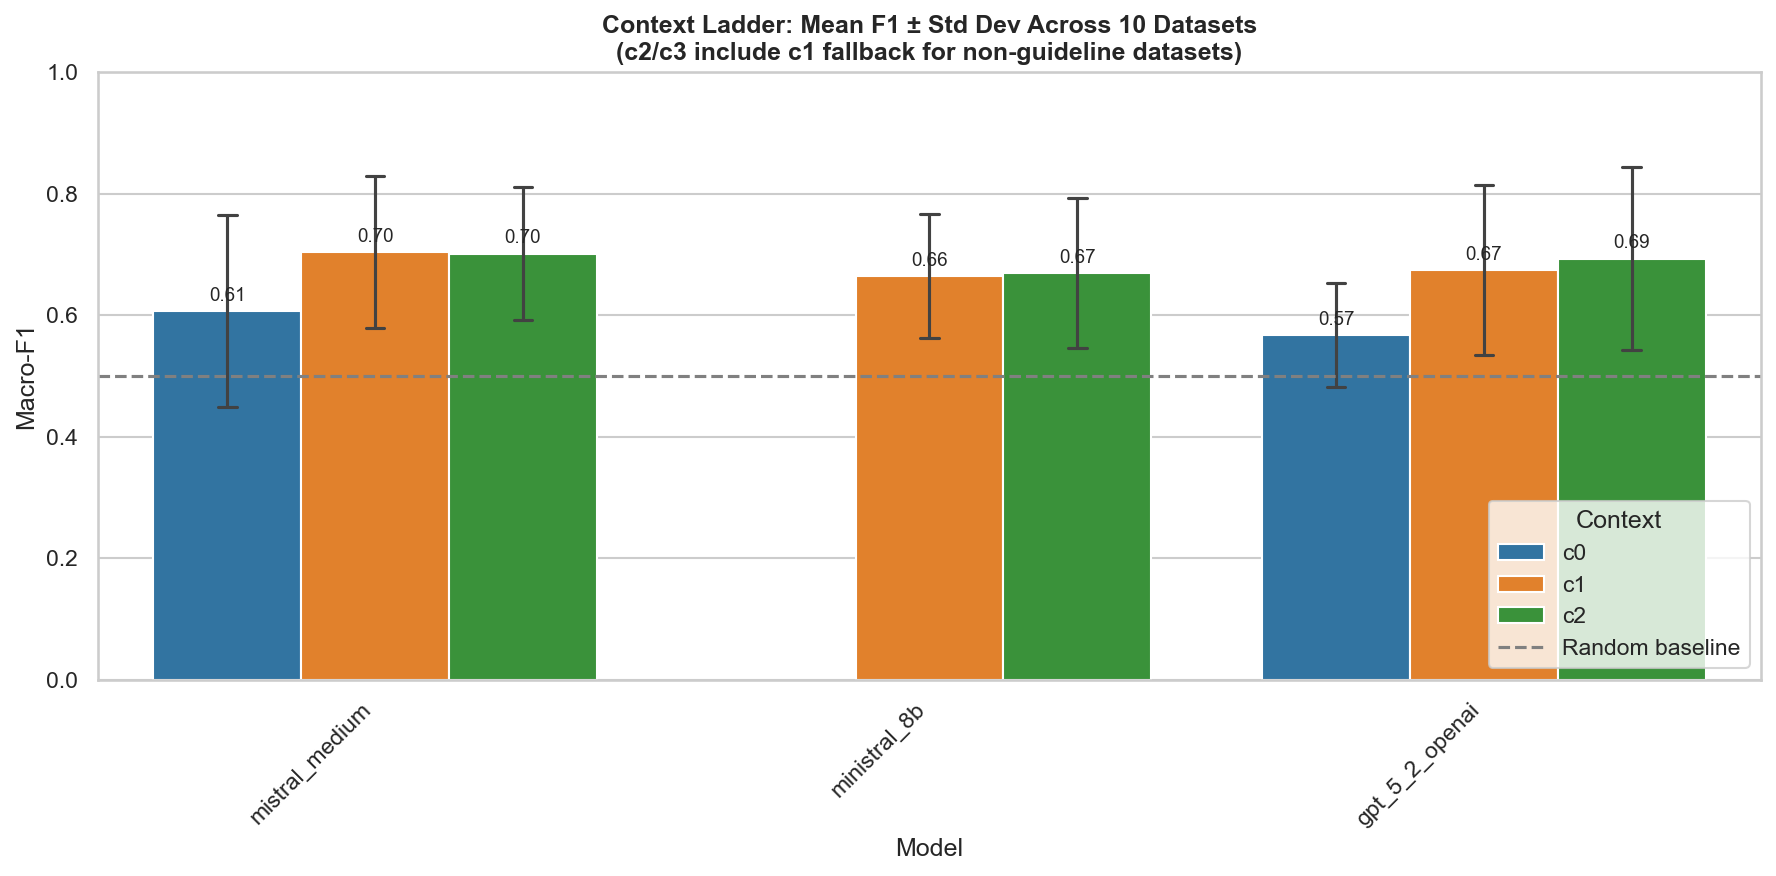

In [13]:
# Bar chart with error bars: F1 mean ± std across 10 datasets
# Using df_filled for fair 10-dataset comparison (c2/c3 include c1 fallback)
if not original_df_filled.empty:
    # Sort contexts
    context_order_list = ["c0", "c1", "c2", "c3"]
    plot_df = original_df_filled.copy()
    plot_df["context"] = pd.Categorical(
        plot_df["context"], 
        categories=[c for c in context_order_list if c in plot_df["context"].unique()],
        ordered=True
    )
    
    # Sort models by mean F1 descending
    model_order = plot_df.groupby("model_dir")["macro_f1"].mean().sort_values(ascending=False).index.tolist()
    
    # Build color palette from CONTEXT_COLORS
    available_contexts = [c for c in context_order_list if c in plot_df["context"].unique()]
    palette = [CONTEXT_COLORS.get(c, "#333333") for c in available_contexts]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=plot_df, x="model_dir", y="macro_f1", hue="context",
                order=model_order, palette=palette, ax=ax,
                errorbar="sd", capsize=0.1, err_kws={"linewidth": 1.5})
    
    # Add value labels on bars (mean values)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)
    
    # Random baseline reference line
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.5, label="Random baseline")
    
    ax.set_title("Context Ladder: Mean F1 ± Std Dev Across 10 Datasets\n(c2/c3 include c1 fallback for non-guideline datasets)", fontweight="bold")
    ax.set_xlabel("Model")
    ax.set_ylabel("Macro-F1")
    ax.set_ylim(0, 1)
    ax.legend(title="Context", loc="lower right")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No data available for context ladder")

## Summary Statistics

In [14]:
# Summary: Mean F1, Std by model/context
# Using df_filled for consistent 10-dataset comparison
if not original_df_filled.empty:
    summary = original_df_filled.groupby(["model_dir", "context"])["macro_f1"].agg(["mean", "std", "count"])
    summary.columns = ["Mean F1", "Std", "N Datasets"]
    print("Summary Statistics (Original Text)")
    print("NOTE: c2/c3 include c1 fallback → all contexts show 10 datasets")
    display(summary.round(3))
else:
    print("No data available for summary")

Summary Statistics (Original Text)
NOTE: c2/c3 include c1 fallback → all contexts show 10 datasets


Mean F1    Std  N Datasets
model_dir      context                            
gpt_5_2_openai c0         0.567  0.086          10
               c1         0.674  0.141          10
               c2         0.693  0.151          10
ministral_8b   c1         0.664  0.102          10
               c2         0.670  0.123          10
mistral_medium c0         0.606  0.158          10
               c1         0.704  0.125          10
               c2         0.701  0.109          10

In [15]:
# Export results tables
if len(df) > 0:
    # Raw results (actual experiment outputs only)
    raw_path = V1_DIR / "results_raw.csv"
    df.to_csv(raw_path, index=False)
    print(f"Exported raw results to {raw_path}")
    
    # Filled results (c2/c3 include c1 fallback for non-guideline datasets)
    filled_path = V1_DIR / "results_filled.csv"
    df_filled.to_csv(filled_path, index=False)
    print(f"Exported filled results to {filled_path}")
    print("  -> Use results_filled.csv for aggregate comparisons across context conditions")
else:
    print("No results to export yet")

Exported raw results to /Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/experiments/v3/results_raw.csv
Exported filled results to /Users/hanneswidera/Uni/Master/thesis/GAIC_thesis/experiments/v3/results_filled.csv
  -> Use results_filled.csv for aggregate comparisons across context conditions


## Comprehensive Performance Tables

In [16]:
# =============================================================================
# TABLE 1: F1 Scores by Model x Context x Dataset
# =============================================================================

all_datasets = sorted(df["dataset"].unique())
original_only = df[df["manipulation"] == "original"]

# Pivot: rows = (model_dir, context), columns = dataset
f1_pivot = original_only.pivot_table(
    values="macro_f1",
    index=["model_dir", "context"],
    columns="dataset",
    aggfunc="mean"
)
f1_pivot["Avg"] = f1_pivot.mean(axis=1)

# Sort by context order
context_order = {"c0": 0, "c1": 1, "c2": 2, "c3": 3}
f1_pivot = f1_pivot.sort_index(
    key=lambda x: x.map(lambda v: context_order.get(v, 99)) if x.name == "context" else x
)

print("=== F1 Scores (Original Text) ===\n")
print(f1_pivot.round(3).to_string())

# Enhanced styling: gradient first, then max highlight with border only (no background override)
styled_f1 = f1_pivot.style.background_gradient(
    cmap="RdYlGn", vmin=0.3, vmax=0.8
).highlight_max(
    axis=1, props="font-weight:bold; border:2px solid black"
).format("{:.3f}", na_rep="-")
display(styled_f1)

=== F1 Scores (Original Text) ===

dataset                 ABSTRCT  ACQUA    AEC    AFS  ARGUMINSCI  FINARG    IAM     PE  SCIARK  USELEC    Avg
model_dir      context                                                                                       
gpt_5_2_openai c0         0.692  0.618  0.562  0.569       0.524   0.405  0.563  0.666   0.601   0.472  0.567
               c1         0.663  0.749  0.498  0.767       0.917   0.438  0.764  0.600   0.717   0.630  0.674
               c2         0.883    NaN    NaN    NaN       0.883     NaN    NaN  0.583     NaN   0.649  0.750
ministral_8b   c1         0.833  0.744  0.498  0.699       0.733   0.542  0.681  0.697   0.633   0.580  0.664
               c2         0.950    NaN    NaN    NaN       0.668     NaN    NaN  0.603     NaN   0.679  0.725
mistral_medium c0         0.764  0.732  0.444  0.451       0.576   0.365  0.661  0.641   0.867   0.562  0.606
               c1         0.900  0.764  0.486  0.766       0.757   0.583  0.782  0.60

In [17]:
# =============================================================================
# TABLE 2: Manipulation Sensitivity (Delta values)
# =============================================================================
# More negative delta = larger performance drop = relies on linguistic structure

delta_cols = ["delta_content_only", "delta_shuffle"]
if all(c in deltas_df.columns for c in delta_cols):
    # Aggregate deltas by model/context
    delta_agg = deltas_df.groupby(["model_dir", "context"]).agg({
        "delta_content_only": "mean",
        "delta_shuffle": "mean",
        "dataset": "count"
    }).rename(columns={"dataset": "n_datasets"})
    
    # Add mean absolute delta
    delta_agg["mean_abs_delta"] = (
        delta_agg["delta_content_only"].abs() + delta_agg["delta_shuffle"].abs()
    ) / 2
    
    # Sort by context order
    delta_agg = delta_agg.sort_index(
        key=lambda x: x.map(lambda v: context_order.get(v, 99)) if x.name == "context" else x
    )
    
    print("=== Manipulation Sensitivity (Delta values) ===")
    print("More negative = higher sensitivity to manipulation\n")
    print(delta_agg.round(3).to_string())
    
    # Enhanced styling: gradient + max highlight with border only
    styled_delta = delta_agg.style.background_gradient(
        subset=["delta_content_only", "delta_shuffle"],
        cmap="RdYlGn_r",  # Reversed: negative (green) to positive (red)
        vmin=-0.4, vmax=0.1
    ).background_gradient(
        subset=["mean_abs_delta"],
        cmap="RdYlGn",
        vmin=0.0, vmax=0.3
    ).highlight_max(
        subset=["delta_content_only", "delta_shuffle"],
        axis=0, props="font-weight:bold; border:2px solid black"
    ).format("{:.3f}")
    display(styled_delta)
else:
    print("Insufficient manipulation data for delta analysis")

=== Manipulation Sensitivity (Delta values) ===
More negative = higher sensitivity to manipulation

manipulation            delta_content_only  delta_shuffle  n_datasets  mean_abs_delta
model_dir      context                                                               
gpt_5_2_openai c0                   -0.091         -0.086          10           0.089
               c1                   -0.126         -0.197          10           0.162
               c2                   -0.099         -0.188          10           0.144
ministral_8b   c1                   -0.158         -0.291          10           0.225
               c2                   -0.124         -0.279          10           0.202
mistral_medium c0                   -0.030         -0.148          10           0.089
               c1                   -0.137         -0.247          10           0.192
               c2                   -0.112         -0.221          10           0.166


In [18]:
# =============================================================================
# TABLE 3: F1 by Manipulation (original, content_only, shuffle) per Dataset
# =============================================================================

manip_pivot = df.pivot_table(
    values="macro_f1",
    index=["model_dir", "context", "dataset"],
    columns="manipulation",
    aggfunc="mean"
)

# Reorder columns
col_order = [c for c in ["original", "content_only", "shuffle"] if c in manip_pivot.columns]
manip_pivot = manip_pivot[col_order]
manip_pivot["Avg"] = manip_pivot.mean(axis=1)

# Sort by context order
manip_pivot = manip_pivot.sort_index(
    key=lambda x: x.map(lambda v: context_order.get(v, 99)) if x.name == "context" else x
)

print("=== F1 by Manipulation per Dataset ===\n")
print(manip_pivot.round(3).to_string())

# Enhanced styling: gradient + max highlight with border only
styled_manip = manip_pivot.style.background_gradient(
    cmap="RdYlGn", vmin=0.3, vmax=0.8
).highlight_max(
    axis=1, props="font-weight:bold; border:2px solid black"
).format("{:.3f}", na_rep="-")
display(styled_manip)

=== F1 by Manipulation per Dataset ===

manipulation                       original  content_only  shuffle    Avg
model_dir      context dataset                                           
gpt_5_2_openai c0      ABSTRCT        0.692         0.601    0.601  0.631
                       ACQUA          0.618         0.394    0.538  0.517
                       AEC            0.562         0.449    0.444  0.485
                       AFS            0.569         0.588    0.576  0.578
                       ARGUMINSCI     0.524         0.333    0.333  0.397
                       FINARG         0.405         0.326    0.369  0.367
                       IAM            0.563         0.653    0.569  0.595
                       PE             0.666         0.524    0.533  0.575
                       SCIARK         0.601         0.538    0.524  0.554
                       USELEC         0.472         0.352    0.326  0.383
               c1      ABSTRCT        0.663         0.648    0.506  0.60

## RQ1: Does Additional Context Improve Classification?

This analysis focuses on the 4 datasets where annotation guidelines are available: **ABSTRCT, ARGUMINSCI, PE, USELEC**. These allow testing the full context ladder:

| Level | Context Provided |
|-------|------------------|
| c0 | None (zero-shot baseline) |
| c1 | Definition of "argument" from source paper |
| c2 | c1 + Annotation guideline (what annotators were told) |
| c3 | c2 + Document context (preceding sentences) |

**Why this matters for the thesis:** If LLMs can leverage annotation guidelines to match human annotator behavior, this suggests they can generalize across datasets by adapting to different argument definitions rather than learning dataset-specific shortcuts.

In [ ]:
# =============================================================================
# GUIDELINE DATASETS: Context Ladder c0 → c3
# =============================================================================

# Filter to guideline datasets and original manipulation
guideline_df = df[
    (df["dataset"].isin(GUIDELINE_DATASETS)) & 
    (df["manipulation"] == "original")
].copy()

# Ensure context order
context_order_full = ["c0", "c1", "c2", "c3"]
guideline_df["context"] = pd.Categorical(
    guideline_df["context"],
    categories=[c for c in context_order_full if c in guideline_df["context"].unique()],
    ordered=True
)

# Pivot for grouped bar chart: datasets as groups, contexts as bars
guideline_pivot = guideline_df.pivot_table(
    values="macro_f1",
    index=["model_dir", "dataset"],
    columns="context",
    aggfunc="mean"
).reset_index()

print(f"Guideline datasets available contexts: {sorted(guideline_df['context'].dropna().unique())}")
print(f"Models: {sorted(guideline_df['model_dir'].unique())}")
guideline_pivot

In [ ]:
# =============================================================================
# PLOT 1: Grouped Bar Chart - Context Ladder per Dataset (Faceted by Model)
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

models = sorted(guideline_df["model_dir"].unique())
datasets_ordered = ["ABSTRCT", "ARGUMINSCI", "PE", "USELEC"]
available_contexts = [c for c in context_order_full if c in guideline_df["context"].unique()]

# Extended color palette for c0-c3
CONTEXT_COLORS_FULL = {
    "c0": "#1f77b4",  # blue
    "c1": "#ff7f0e",  # orange  
    "c2": "#2ca02c",  # green
    "c3": "#d62728",  # red
}

for ax, model in zip(axes, models):
    model_data = guideline_df[guideline_df["model_dir"] == model]
    
    # Pivot for this model
    pivot = model_data.pivot_table(
        values="macro_f1",
        index="dataset",
        columns="context",
        aggfunc="mean"
    ).reindex(datasets_ordered)
    
    # Bar positions
    x = np.arange(len(datasets_ordered))
    width = 0.2
    n_contexts = len(available_contexts)
    
    for i, ctx in enumerate(available_contexts):
        if ctx in pivot.columns:
            offset = (i - (n_contexts - 1) / 2) * width
            bars = ax.bar(x + offset, pivot[ctx], width, 
                         label=ctx, color=CONTEXT_COLORS_FULL[ctx], alpha=0.85)
            # Value labels
            ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8, rotation=90)
    
    ax.set_xticks(x)
    ax.set_xticklabels(datasets_ordered, rotation=45, ha="right")
    ax.set_title(model.replace("_", " ").title(), fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.7)

axes[0].set_ylabel("Macro-F1")
axes[0].legend(title="Context", loc="upper left")

fig.suptitle("Context Ladder: Guideline Datasets (c0 → c3)", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(V1_DIR / "plot_guideline_context_ladder.png", dpi=150, bbox_inches="tight")
plt.show()

### Observations

**Definition helps consistently (c0 → c1):** All models show improvement when given a definition. The effect is strongest on ARGUMINSCI (+0.18 to +0.39 F1), where the zero-shot baseline is near random.

**Guidelines help selectively (c1 → c2):** ABSTRCT and USELEC benefit from guidelines across models. ARGUMINSCI shows mixed results — GPT-5.2 drops slightly while Mistral stays flat. This suggests guidelines are most useful when the definition alone is ambiguous.

**Document context is unreliable (c2 → c3):** Adding preceding sentences hurts PE consistently (all models drop). USELEC is the only dataset where c3 outperforms c2. This matches the hypothesis that document context can introduce noise when sentences are self-contained.

**PE is an outlier:** Performance degrades with more context across all models. This dataset may have annotation criteria that conflict with what the model infers from guidelines.

In [ ]:
# =============================================================================
# Context Impact Deltas: How much does each context level add?
# =============================================================================

# Calculate deltas: c1-c0, c2-c1, c3-c2
context_deltas = []
for model in guideline_df["model_dir"].unique():
    for dataset in GUIDELINE_DATASETS:
        model_ds = guideline_df[(guideline_df["model_dir"] == model) & 
                                 (guideline_df["dataset"] == dataset)]
        
        f1_by_ctx = model_ds.set_index("context")["macro_f1"].to_dict()
        
        row = {"model": model, "dataset": dataset}
        row["c0"] = f1_by_ctx.get("c0", np.nan)
        row["c1"] = f1_by_ctx.get("c1", np.nan)
        row["c2"] = f1_by_ctx.get("c2", np.nan)
        row["c3"] = f1_by_ctx.get("c3", np.nan)
        
        # Deltas
        if "c0" in f1_by_ctx and "c1" in f1_by_ctx:
            row["Δ(c1-c0)"] = f1_by_ctx["c1"] - f1_by_ctx["c0"]
        if "c1" in f1_by_ctx and "c2" in f1_by_ctx:
            row["Δ(c2-c1)"] = f1_by_ctx["c2"] - f1_by_ctx["c1"]
        if "c2" in f1_by_ctx and "c3" in f1_by_ctx:
            row["Δ(c3-c2)"] = f1_by_ctx["c3"] - f1_by_ctx["c2"]
        
        context_deltas.append(row)

context_delta_df = pd.DataFrame(context_deltas)

print("=== Context Impact Deltas (Guideline Datasets) ===")
print("Positive = improvement, Negative = degradation\n")

# Style the delta columns
delta_cols = [c for c in context_delta_df.columns if c.startswith("Δ")]
styled = context_delta_df.style.background_gradient(
    subset=delta_cols,
    cmap="RdYlGn",
    vmin=-0.2, vmax=0.2
).format("{:.3f}", subset=["c0", "c1", "c2", "c3"] + delta_cols, na_rep="-")
display(styled)

### Context Impact Summary

The table above shows absolute F1 at each context level and the delta between consecutive levels. Green = improvement, red = degradation.

**Key findings:**
- Δ(c1-c0) is positive for 10/12 model×dataset combinations — definitions help almost universally
- Δ(c2-c1) is positive for only 6/12 — guidelines are dataset-dependent  
- Δ(c3-c2) is negative for 7/12 — document context often hurts

**Implication:** The optimal context level is not "more is better." For some datasets (PE), zero-shot outperforms the full context stack. The thesis should investigate what makes certain datasets respond negatively to additional context.

## RQ2: Which Datasets Remain Challenging?

This plot shows the performance spread for each dataset across all model × context combinations. The gray bar spans from the worst to best configuration; markers show lowest (red), average (orange), and best (green) F1.

**Why this matters for the thesis:** Datasets with high variance suggest performance depends heavily on choosing the right model/context — the task itself is tractable. Datasets where even the best configuration is near 0.5 indicate a fundamental difficulty that no current approach solves.

In [ ]:
# =============================================================================
# PLOT 2: Best / Average / Lowest Performance per Dataset
# =============================================================================

# Get original text only
original_only = df[df["manipulation"] == "original"]

# Aggregate by dataset: min, mean, max across all model×context combinations
dataset_perf = original_only.groupby("dataset")["macro_f1"].agg(["min", "mean", "max"])
dataset_perf.columns = ["Lowest", "Average", "Best"]

# Find best configuration for each dataset
best_configs = []
for dataset in dataset_perf.index:
    ds_data = original_only[original_only["dataset"] == dataset]
    best_idx = ds_data["macro_f1"].idxmax()
    best_row = ds_data.loc[best_idx]
    best_configs.append({
        "dataset": dataset,
        "best_config": f"{best_row['model_dir']} ({best_row['context']})",
        "best_f1": best_row["macro_f1"]
    })
best_config_df = pd.DataFrame(best_configs).set_index("dataset")

# Merge
dataset_perf = dataset_perf.join(best_config_df)

# Sort by best F1
dataset_perf = dataset_perf.sort_values("Best", ascending=True)

print("=== Performance Range per Dataset ===\n")
display(dataset_perf.round(3))

In [ ]:
# =============================================================================
# Horizontal Bar Chart: Performance Range per Dataset
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 8))

datasets = dataset_perf.index.tolist()
y_pos = np.arange(len(datasets))

# Draw range bars (min to max)
for i, ds in enumerate(datasets):
    row = dataset_perf.loc[ds]
    # Range bar (light gray)
    ax.barh(i, row["Best"] - row["Lowest"], left=row["Lowest"], 
            height=0.6, color="#cccccc", alpha=0.8, edgecolor="none")
    
    # Lowest marker (red)
    ax.scatter(row["Lowest"], i, color="#d62728", s=100, zorder=3, 
               marker="<", label="Lowest" if i == 0 else "")
    
    # Average marker (orange)
    ax.scatter(row["Average"], i, color="#ff7f0e", s=120, zorder=3, 
               marker="o", label="Average" if i == 0 else "")
    
    # Best marker (green)
    ax.scatter(row["Best"], i, color="#2ca02c", s=100, zorder=3, 
               marker=">", label="Best" if i == 0 else "")
    
    # Best config annotation
    ax.annotate(f'{row["best_config"]}', 
                xy=(row["Best"] + 0.02, i), 
                va="center", fontsize=9, color="#2ca02c")

ax.set_yticks(y_pos)
ax.set_yticklabels(datasets)
ax.set_xlabel("Macro-F1")
ax.set_xlim(0.2, 1.1)
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="Random baseline")

ax.legend(loc="lower right")
ax.set_title("Performance Range per Dataset\n(across all Model × Context combinations)", fontweight="bold")

plt.tight_layout()
plt.savefig(V1_DIR / "plot_dataset_performance_range.png", dpi=150, bbox_inches="tight")
plt.show()

### Observations

**High-performing datasets (F1 > 0.85):**
- ABSTRCT (0.95) and ARGUMINSCI (0.92) reach near-human performance with the right configuration
- Both benefit from guidelines (c2) — this supports the GAIC task hypothesis that context enables generalization

**Challenging datasets (F1 < 0.6):**
- AEC (0.56) and FINARG (0.58) barely exceed random baseline even with the best model/context
- These may require domain-specific knowledge (architecture, finance) not captured by general LLMs

**High variance datasets:**
- ARGUMINSCI has the largest range (0.42) — zero-shot fails but with definition it works
- This is evidence that context compensates for lack of dataset-specific training

**Best configurations are not uniform:**
- No single model dominates — mistral_medium wins on 4 datasets, GPT-5.2 on 3, ministral_8b on 3
- Context level varies: c0 wins for SCIARK (contamination?), c3 wins for USELEC
- This suggests model selection should be dataset-aware in practice

In [ ]:
# =============================================================================
# Summary: Best Configuration per Dataset
# =============================================================================

# Create clean summary table
summary_table = dataset_perf[["best_config", "Best", "Lowest", "Average"]].copy()
summary_table["Range"] = summary_table["Best"] - summary_table["Lowest"]
summary_table = summary_table.sort_values("Best", ascending=False)
summary_table.columns = ["Best Config", "Best F1", "Lowest F1", "Avg F1", "Range"]

print("=== Best Configuration per Dataset ===")
print("Sorted by Best F1 descending\n")

styled = summary_table.style.background_gradient(
    subset=["Best F1", "Lowest F1", "Avg F1"],
    cmap="RdYlGn", vmin=0.3, vmax=0.95
).background_gradient(
    subset=["Range"],
    cmap="Blues", vmin=0, vmax=0.4
).format("{:.3f}", subset=["Best F1", "Lowest F1", "Avg F1", "Range"])
display(styled)